In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm

from scipy.linalg import block_diag
from collections import deque

import kind
import ex_duffing
import util_data
import util_nn
import reinforcement_learning as rl

In [2]:
# --! define Duffing parameters --!

# --! define parameters of a nominal Duffing which is supposed to be stabilized by an LQR
duffing_alpha_nom = -1.0
duffing_delta_nom = 0.5

# --! define parameters of an anomalous Duffing which exhibits excursions from one well to the other
duffing_alpha = -110.0
duffing_beta = 140.0
duffing_gamma = 70.0
duffing_delta = duffing_delta_nom

In [3]:
# --! make a base policy --!

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 10.0 * np.eye(action_ndim)

# --! we aim to capture the Duffing in well (1,0)
setpoint = [1.0, 0.0]
dt = 1e-2

base_policy, p = ex_duffing.make_base_policy(
    duffing_alpha_nom, duffing_delta_nom,
    q=state_cost, r=action_cost,
    dt=dt,
    setpoint=setpoint)


In [4]:
# --! define a Duffing reward function --!

reward_fn = ex_duffing.duffing_reward(p, action_cost, setpoint, alpha=duffing_alpha, beta=duffing_beta, lambda_E=0.05)

In [5]:
# --! make a Duffing oscillator --!

duffing = ex_duffing.duffing(
    reward_fn,
    alpha=duffing_alpha, beta=duffing_beta, gamma=duffing_gamma, delta=duffing_delta,
    dt_control=dt)

duffing = ex_duffing.duffing_adapter(duffing)

In [6]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '122',
        '--data_nsample_exc', '528',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--lookback_nsample', '64',
        '--forecast_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '32',
        '--seg_nsample_trans', '16',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

# --! instantiate a KIND model
model = kind.model(args)

# --! load trained weights into the model
model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=False)

model = kind.model_adapter(model, dataset.normalizer)

In [7]:
train_loader, _, _ = dataset.load(data_type='nom')
zeta = []

with torch.no_grad():
    for back, fore in train_loader:

        model_o = model(back)
        zeta_nom = model_o.zeta_nom

        zeta.append(torch.mean(zeta_nom).item())

zeta = torch.tensor(zeta, dtype=torch.float32)
zeta_nom_nom = torch.mean(zeta)

train_loader, _, _ = dataset.load(data_type='exc')
zeta = []

with torch.no_grad():
    for back, fore in train_loader:

        model_o = model(back)
        zeta_nom = model_o.zeta_nom

        zeta.append(torch.mean(zeta_nom).item())

zeta = torch.tensor(zeta, dtype=torch.float32)
zeta_nom_exc = torch.mean(zeta)

zeta_star = kind.regimes(zeta_nom_nom, zeta_nom_exc)

print(zeta_star)
#print(tata.shape)

regimes(nominal=tensor(0.0237), excursion=tensor(0.9903))


In [8]:
nsample = args.lookback_nsample
zeta = torch.tensor(0.0)
duffing_ic = torch.zeros(1,1,2)

replay_factory = ex_duffing.replay_factory()
replay = replay_factory.create(duffing, duffing_ic, rl.policies(base_policy, None), zeta, zeta_star, nsample, 10*nsample)

>>> replay factory: skipping 640 samples
>>> replay factory: skipped 640 samples


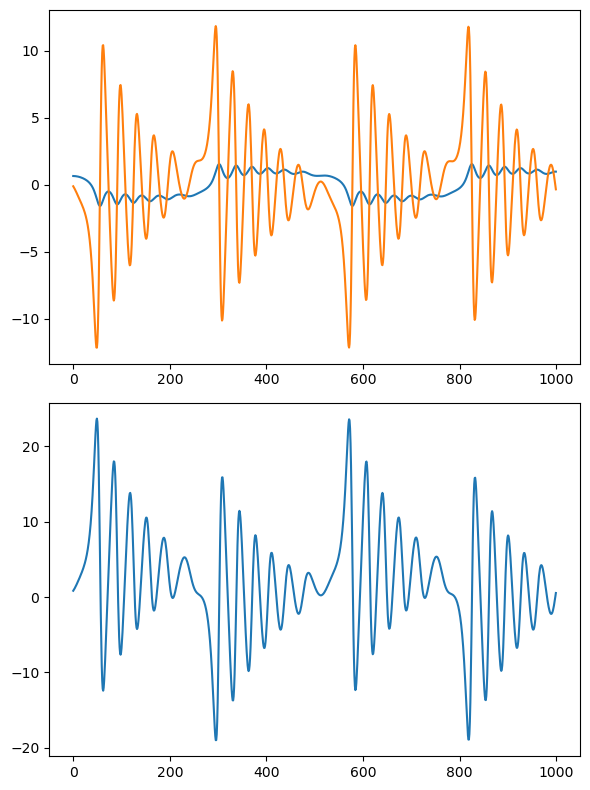

In [9]:
state, reward, next_state, done = map(torch.cat, zip(*replay.buffer))
s = replay_factory.extract_current_s(state)
a = replay_factory.extract_current_a(state)

with torch.no_grad():
    plt.figure(figsize=(6,8))

    plt.subplot(2,1,1)
    plt.plot(s[:1000, 0, :2])

    plt.subplot(2,1,2)
    plt.plot(a[:1000, 0, :])

    plt.tight_layout()
    plt.show()

#print(tata.shape)

In [10]:

pi = rl.policy_iteration(base_policy, duffing.reward_fn, dataset.normalizer)
loss = pi.evaluate_policy(replay_factory, replay)


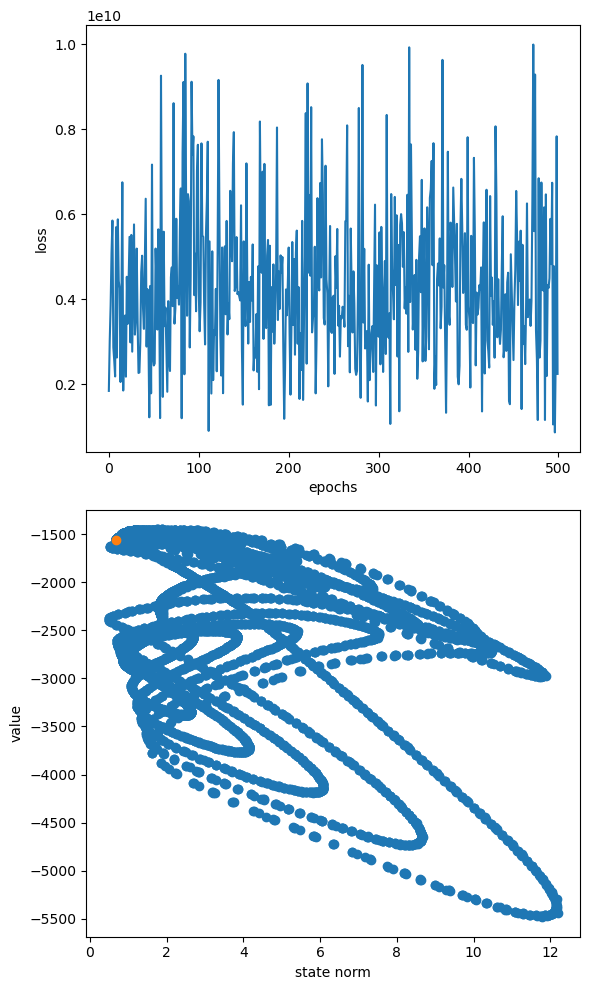

In [11]:

pi.value_fn.eval()

state, reward, next_state, done = map(torch.cat, zip(*replay.buffer))
s = replay_factory.extract_current_s(state)
s_norm = torch.squeeze(torch.linalg.norm(s, dim=-1, ord=2))
value = torch.squeeze(pi.value_fn(s))

with torch.no_grad():

    plt.figure(figsize=(6,10))

    plt.subplot(2,1,1)
    plt.plot(loss)
    plt.xlabel('epochs')
    plt.ylabel('loss')

    plt.subplot(2,1,2)
    plt.scatter(s_norm, value)
    plt.scatter(s_norm[0], value[0])
    plt.xlabel('state norm')
    plt.ylabel('value')

    plt.tight_layout()
    plt.show()

#print(tata.shape)

In [12]:
loss = pi.improve_policy(model, zeta_star, replay_factory, replay, duffing)

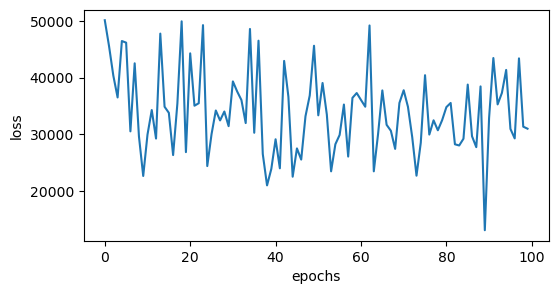

In [13]:
with torch.no_grad():

    plt.figure(figsize=(6,3))

    plt.plot(loss)
    plt.xlabel('epochs')
    plt.ylabel('loss')

    plt.show()

#print(tata.shape)

In [14]:
pi.residual_policy.eval()

with torch.no_grad():
    replay2 = replay_factory.create(
        duffing, duffing_ic,
        rl.policies(base_policy, pi.residual_policy),
        zeta_star.nominal, zeta_star,
        nsample, 10*nsample)

print(zeta_star)

>>> replay factory: skipping 640 samples
>>> replay factory: skipped 640 samples
regimes(nominal=tensor(0.0237), excursion=tensor(0.9903))


In [15]:
replay_data = map(torch.cat, zip(*replay2.buffer))

pi.value_fn.eval()
pi.residual_policy.eval()

horizon = 1
gamma = 0.995

with torch.no_grad():
    adv = rl.advantage(
        model, zeta_star,
        rl.policies(pi.base_policy, pi.residual_policy),
        pi.reward_fn,
        pi.value_fn,
        dataset.normalizer,
        replay_factory, replay_data, duffing,
        horizon, gamma
    )


tensor([[[3.3628]]])
tensor([[[3.5163]]])


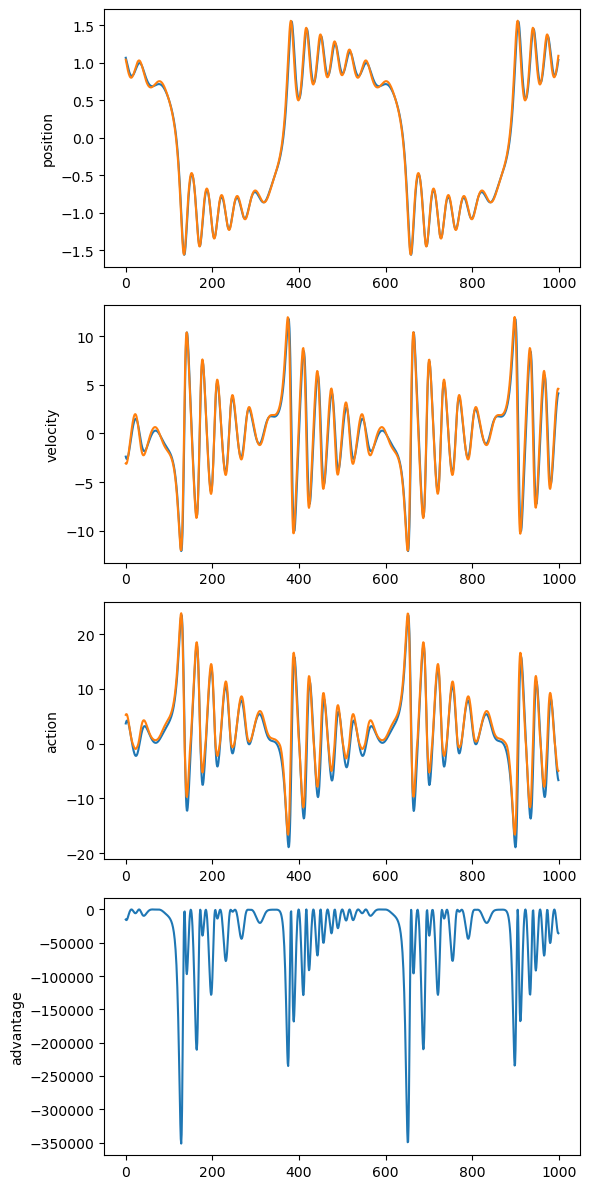

In [16]:
lookback, reward, next_lookback, done = map(torch.cat, zip(*replay.buffer))
state1 = replay_factory.extract_current_s(lookback)
action1 = replay_factory.extract_current_a(lookback)

state_norm1 = torch.linalg.norm(state1, dim=-1, keepdim=True)
print(torch.mean(state_norm1, dim=0, keepdim=True))

lookback, reward, next_lookback, done = map(torch.cat, zip(*replay2.buffer))
state2 = replay_factory.extract_current_s(lookback)
action2 = replay_factory.extract_current_a(lookback)

state_norm2 = torch.linalg.norm(state2, dim=-1, keepdim=True)
print(torch.mean(state_norm2, dim=0, keepdim=True))

with torch.no_grad():

    plt.figure(figsize=(6,12))

    plt.subplot(4,1,1)
    plt.plot(state1[-1000:, 0, 0])
    plt.plot(state2[-1000:, 0, 0])
    #plt.plot([580,580],[-1.5,1.5], linestyle='dashed', color='gray')
    #plt.plot([600,600],[-1.5,1.5], linestyle='dashed', color='gray')
    plt.ylabel('position')

    plt.subplot(4,1,2)
    plt.plot(state1[-1000:, 0, 1])
    plt.plot(state2[-1000:, 0, 1])
    plt.ylabel('velocity')

    plt.subplot(4,1,3)
    plt.plot(action1[-1000:, 0, :])
    plt.plot(action2[-1000:, 0, :])
    plt.ylabel('action')

    plt.subplot(4,1,4)
    plt.plot(adv[-1000:, 0, 0])
    #plt.ylim((-100, 100))
    plt.ylabel('advantage')

    plt.tight_layout()
    plt.show()

    datasaved = False

    if datasaved:
        step = torch.arange(1000).reshape(1, -1, 1)
        step = step - 300

        state11 = state1[-1000:, :1, :1].reshape(1, -1, 1)
        state12 = state1[-1000:, :1, 1:2].reshape(1, -1, 1)
        action11 = action1[-1000:, :1, :1].reshape(1, -1, 1)

        state21 = state2[-1000:, :1, :1].reshape(1, -1, 1)
        state22 = state2[-1000:, :1, 1:2].reshape(1, -1, 1)
        action21 = action2[-1000:, :1, :1].reshape(1, -1, 1)
        adv21 = adv[-1000:, :1, :1].reshape(1, -1, 1)
        adv21 = adv21 / 1e6

        #savedata = np.concatenate([
            #step,
            #state11, state12, action11], axis=2)
        #util_data.write_datafile(f'../../results/dreamer/duffing_kindrl_baseline', savedata, delim=' ')

        savedata = np.concatenate([
            step,
            state21, state22, action21, adv21], axis=2)
        util_data.write_datafile(f'../../results/dreamer/duffing_kindrl_h1_gamma0995_umax01', savedata, delim=' ')

#print(tata.shape)

In [17]:
def cumulative_cost(states, actions, Q, R, lambda_E, alpha, beta):

    total = 0.0
    for x, u in zip(states, actions):
        x = x.reshape(-1, 1)
        u = u.reshape(-1, 1)

        state_cost = x.T @ Q @ x
        action_cost = u.T @ R @ u

        # Duffing energy
        q, qdot = x[0, 0], x[1, 0]
        energy = 0.5*qdot**2 + 0.5*alpha*q**2 + 0.25*beta*q**4

        total += state_cost.item() + action_cost.item() + lambda_E * energy
    
    return total

def residence_time_energy(states, alpha, beta):
    total = 0
    for x in states:
        q, qdot = x
        energy = 0.5*qdot**2 + 0.5*alpha*q**2 + 0.25*beta*q**4
        if q > 0 and energy < 0:
            total += 1
    return total

def rms_control(actions):
    return np.sqrt(np.mean(actions**2))

def escape_time(states):
    for i, x in enumerate(states):
        if x[0] < 0:   # crossed to bad well
            return i
    return len(states)

s1 = state1.reshape(-1, 2).numpy()
s2 = state2.reshape(-1, 2).numpy()
a1 = action1.reshape(-1, 1).numpy()
a2 = action2.reshape(-1, 1).numpy()

cost1 = cumulative_cost(s1, a1, p, action_cost, 0.05, duffing_alpha, duffing_beta)
cost2 = cumulative_cost(s2, a2, p, action_cost, 0.05, duffing_alpha, duffing_beta)

steps1 = residence_time_energy(s1, duffing_alpha, duffing_beta)
steps2 = residence_time_energy(s2, duffing_alpha, duffing_beta)

effort1 = rms_control(a1)
effort2 = rms_control(a2)

escape1 = escape_time(s1)
escape2 = escape_time(s2)

print(cost1)
print(cost2)

print(steps1)
print(steps2)

print(effort1)
print(effort2)

print(escape1)
print(escape2)

287093660.0
305006200.0
3477
3357
7.2158237
7.136981
38
38


In [18]:
#torch.save(pi.residual_policy.state_dict(), '../../models/dreamer' + '/' + 'policy_checkpoint.pth')